https://chatgpt.com/share/69e4e1eb-81c0-839c-9557-7e47e90fc139

In [3]:
!pip install gurobipy

import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests, io
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 35.9 MB/s eta 0:00:00


In [4]:
# This is the hosted link to the dataset with only VehicleID=0
# Cleaned from https://www.kaggle.com/datasets/ranatariq09/vehicular-simulation-dataset-veins-omnet/data vehicular_dataset_2025-01-01.csv
dataset = requests.get("http://update.starisle.cn/vehicular_sample.csv").content

In [5]:
df = pd.read_csv(io.BytesIO(dataset))
print(f"Dataset loaded: {len(df):,} rows, {df.shape[1]} columns")

# Local latency proxy
df["c_local"] = df["TaskSize"] / (df["CPU_Available"] / 100)
# Cloud latency = network round-trip
df["c_cloud"] = df["NetworkLatency"]

# Normalize both to [0,1]
c_min = min(df["c_local"].min(), df["c_cloud"].min())
c_max = max(df["c_local"].max(), df["c_cloud"].max())
df["c_local"] = (df["c_local"] - c_min) / (c_max - c_min)
df["c_cloud"] = (df["c_cloud"] - c_min) / (c_max - c_min)

# Safety constraint: force local when signal is weak or storm
df["force_local"] = (
    (df["SignalStrength"] < -110) |
    (df["WeatherCondition"] == "Storm")
).astype(int)

print(f"\nforce_local trigger rate : {df['force_local'].mean():.1%}")
print(f"  signal  < -110 dBm     : {(df['SignalStrength'] < -110).mean():.1%}")
print(f"  storm weather          : {(df['WeatherCondition'] == 'Storm').mean():.1%}")

Dataset loaded: 8,640 rows, 50 columns

force_local trigger rate : 10.9%
  signal  < -110 dBm     : 10.9%
  storm weather          : 0.0%


In [6]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB


def sample_tasks(data: pd.DataFrame, n: int = 500, seed: int = 42) -> pd.DataFrame:
    """
    Stratified sample tasks by TaskType.

    Procedure:
    1. Compute per_type = max(1, n // number of unique TaskType values)
    2. For each TaskType group, sample min(len(group), per_type)
    3. Combine all sampled groups
    4. Take exactly n rows from the combined result if possible
    5. Reset index and add task_id = index

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing at least the 'TaskType' column.
    n : int, default=500
        Target number of sampled rows.
    seed : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Sampled dataframe with reset index and task_id column.
    """
    if "TaskType" not in data.columns:
        raise ValueError("Input DataFrame must contain a 'TaskType' column.")

    n_types = data["TaskType"].nunique()
    if n_types == 0:
        raise ValueError("No TaskType values found in the input DataFrame.")

    per_type = max(1, n // n_types)

    sampled_groups = []
    for _, g in data.groupby("TaskType", group_keys=False):
        k = min(len(g), per_type)
        sampled_groups.append(g.sample(n=k, random_state=seed))

    combined = pd.concat(sampled_groups, axis=0)

    # Take exactly n rows from the combined result if there are more than n.
    # If fewer than n are available, return all available rows.
    if len(combined) > n:
        combined = combined.sample(n=n, random_state=seed)

    combined = combined.reset_index(drop=True).copy()
    combined["task_id"] = combined.index

    return combined


def compute_cpu_cap(data: pd.DataFrame, buffer: float = 0.8, n: int = 500) -> float:
    """
    Compute CPU capacity limit.

    Formula:
        mean(CPU_Available) * buffer * n / 10

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing 'CPU_Available'.
    buffer : float, default=0.8
        Scaling buffer applied to the mean CPU availability.
    n : int, default=500
        Number of tasks used in scaling.

    Returns
    -------
    float
        Computed CPU capacity.
    """
    if "CPU_Available" not in data.columns:
        raise ValueError("Input DataFrame must contain 'CPU_Available'.")

    return data["CPU_Available"].mean() * buffer * n / 10


def solve_ilp(df_s: pd.DataFrame, cpu_cap: float, label: str = "ILP") -> dict:
    """
    Solve the binary ILP:

    Decision:
        x[i] in {0,1}
        x[i] = 1 => task i assigned to cloud
        x[i] = 0 => task i assigned locally

    Objective:
        min sum((1-x[i]) * c_local[i] + x[i] * c_cloud[i])

    Constraints:
        C1: x[i] <= 1 - force_local[i]           for all i
        C2: sum((1-x[i]) * TaskSize[i]) <= cpu_cap

    Parameters
    ----------
    df_s : pd.DataFrame
        Sampled task dataframe containing:
        'TaskSize', 'c_local', 'c_cloud', 'force_local'.
    cpu_cap : float
        Total local CPU capacity available.
    label : str, default="ILP"
        Model name.

    Returns
    -------
    dict
        {
            "status": gurobi_status_code,
            "obj_val": objective_value_or_None,
            "actual_cost": objective_value_or_None,
            "cloud_count": number_of_cloud_tasks_or_None,
            "decisions": list_of_0_1_or_None
        }
    """
    required_cols = ["TaskSize", "c_local", "c_cloud", "force_local"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    model = gp.Model(label)
    model.setParam("OutputFlag", 0)

    idx = list(df_s.index)

    # Binary assignment variables: 1 = cloud, 0 = local
    x = model.addVars(idx, vtype=GRB.BINARY, name="x")

    # Objective: routing cost
    model.setObjective(
        gp.quicksum(
            (1 - x[i]) * df_s.at[i, "c_local"] + x[i] * df_s.at[i, "c_cloud"]
            for i in idx
        ),
        GRB.MINIMIZE
    )

    # C1: forced-local tasks cannot go to cloud
    model.addConstrs(
        (x[i] <= 1 - int(df_s.at[i, "force_local"]) for i in idx),
        name="force_local"
    )

    # C2: local workload must not exceed CPU capacity
    model.addConstr(
        gp.quicksum((1 - x[i]) * df_s.at[i, "TaskSize"] for i in idx) <= cpu_cap,
        name="cpu_cap"
    )

    model.optimize()

    result = {
        "status": model.Status,
        "obj_val": None,
        "actual_cost": None,
        "cloud_count": None,
        "decisions": None,
    }

    if model.Status in {GRB.OPTIMAL, GRB.SUBOPTIMAL, GRB.TIME_LIMIT} and model.SolCount > 0:
        decisions = [int(round(x[i].X)) for i in idx]
        obj_val = model.ObjVal
        cloud_count = sum(decisions)

        result.update({
            "obj_val": obj_val,
            "actual_cost": obj_val,
            "cloud_count": cloud_count,
            "decisions": decisions,
        })

    return result


def baseline_costs(df_s: pd.DataFrame, cpu_cap: float) -> tuple[float, float]:
    """
    Compute two baseline costs.

    1) Greedy-Local:
       Iterate rows in order.
       - If force_local == 1, assign local
       - Else if local_used + TaskSize <= cpu_cap, assign local
       - Else assign cloud

    2) Greedy-Cloud:
       Iterate rows in order.
       - If force_local == 1, assign local
       - Else assign cloud

    Parameters
    ----------
    df_s : pd.DataFrame
        Task dataframe containing:
        'TaskSize', 'c_local', 'c_cloud', 'force_local'.
    cpu_cap : float
        Total local CPU capacity.

    Returns
    -------
    tuple[float, float]
        (cost_local, cost_cloud)
    """
    required_cols = ["TaskSize", "c_local", "c_cloud", "force_local"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Baseline 1: Greedy-Local
    cost_local = 0.0
    local_used = 0.0

    for _, row in df_s.iterrows():
        if int(row["force_local"]) == 1:
            cost_local += row["c_local"]
            local_used += row["TaskSize"]
        elif local_used + row["TaskSize"] <= cpu_cap:
            cost_local += row["c_local"]
            local_used += row["TaskSize"]
        else:
            cost_local += row["c_cloud"]

    # Baseline 2: Greedy-Cloud
    cost_cloud = 0.0

    for _, row in df_s.iterrows():
        if int(row["force_local"]) == 1:
            cost_cloud += row["c_local"]
        else:
            cost_cloud += row["c_cloud"]

    return cost_local, cost_cloud

In [7]:
# =========================
# PARAMETERS
# =========================

# Number of tasks per run
N = 800

# CPU capacity buffer:
# fraction of mean CPU_Available committed to local execution
BUFFER = 0.8

# Random seed for reproducible sampling
SEED = 42


# =========================
# DERIVED COST COLUMNS
# =========================

# Local execution latency proxy:
# c_local[i] = TaskSize[i] / (CPU_Available[i] / 100)
df["c_local"] = df["TaskSize"] / (df["CPU_Available"] / 100.0)

# Cloud execution latency:
# c_cloud[i] = NetworkLatency[i]
df["c_cloud"] = df["NetworkLatency"]


# =========================
# SUMMARY STATS
# =========================

c_local_mean = df["c_local"].mean()
c_local_min = df["c_local"].min()
c_local_max = df["c_local"].max()

c_cloud_mean = df["c_cloud"].mean()
c_cloud_min = df["c_cloud"].min()
c_cloud_max = df["c_cloud"].max()

print(f"N = {N}, BUFFER = {BUFFER}, SEED = {SEED}")
print()
print(f"c_local mean: {c_local_mean:.4f}")
print(f"c_local range: [{c_local_min:.4f}, {c_local_max:.4f}]")
print()
print(f"c_cloud mean: {c_cloud_mean:.4f}")
print(f"c_cloud range: [{c_cloud_min:.4f}, {c_cloud_max:.4f}]")

N = 800, BUFFER = 0.8, SEED = 42

c_local mean: 14.2119
c_local range: [1.0301, 96.3064]

c_cloud mean: 104.2361
c_cloud range: [10.0055, 199.9503]


In [8]:
# =========================
# HELPER FUNCTIONS — MODEL 1
# =========================

import pandas as pd
import gurobipy as gp
from gurobipy import GRB


def sample_tasks(data: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """
    Stratified sample by TaskType.

    Sampling logic:
    - Compute per_type = max(1, n // number_of_task_types)
    - Sample up to per_type rows from each TaskType group
    - Combine all sampled rows
    - If combined rows exceed n, down-sample to exactly n
    - Reset index and create task_id column

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing at least 'TaskType'.
    n : int
        Target number of sampled tasks.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Sampled dataframe with reset index and a 'task_id' column.
    """
    if "TaskType" not in data.columns:
        raise ValueError("Input data must contain a 'TaskType' column.")

    n_types = data["TaskType"].nunique()
    if n_types == 0:
        raise ValueError("No TaskType values found.")

    per_type = max(1, n // n_types)

    sampled_parts = []
    for _, g in data.groupby("TaskType", group_keys=False):
        take = min(len(g), per_type)
        sampled_parts.append(g.sample(n=take, random_state=seed))

    sampled = pd.concat(sampled_parts, axis=0)

    # If more than n rows were collected, trim to exactly n.
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=seed)

    sampled = sampled.reset_index(drop=True).copy()
    sampled["task_id"] = sampled.index

    return sampled


def compute_cpu_cap(data: pd.DataFrame, buffer: float, n: int) -> float:
    """
    Compute the local CPU capacity upper bound.

    Formula:
        cpu_cap = mean(CPU_Available) * buffer * n / 10

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing 'CPU_Available'.
    buffer : float
        Fraction of mean CPU capacity to commit.
    n : int
        Number of tasks in the sampled run.

    Returns
    -------
    float
        Local CPU capacity upper bound.
    """
    if "CPU_Available" not in data.columns:
        raise ValueError("Input data must contain 'CPU_Available'.")

    return data["CPU_Available"].mean() * buffer * n / 10


def solve_ilp(df_s: pd.DataFrame, cpu_cap: float, label: str):
    """
    Solve Model 1 ILP with Gurobi.

    Decision variable
    -----------------
    x[i] = 1 if task i is assigned to cloud
    x[i] = 0 if task i is assigned locally

    Objective
    ---------
    Minimize:
        sum((1 - x[i]) * c_local[i] + x[i] * c_cloud[i])

    Constraints
    -----------
    C1: x[i] <= 1 - force_local[i]          for all i
        - If force_local[i] = 1, then x[i] must be 0

    C2: sum((1 - x[i]) * TaskSize[i]) <= cpu_cap
        - Total local workload cannot exceed local CPU capacity

    Parameters
    ----------
    df_s : pd.DataFrame
        Sampled dataframe containing:
        'task_id', 'TaskSize', 'c_local', 'c_cloud', 'force_local'
    cpu_cap : float
        Local capacity upper bound.
    label : str
        Model name.

    Returns
    -------
    dict
        {
            "status": solver_status_code,
            "actual_cost": objective_value or None,
            "cloud_count": number_of_cloud_tasks or None,
            "decisions": list of 0/1 decisions or None
        }
    """
    required_cols = ["task_id", "TaskSize", "c_local", "c_cloud", "force_local"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    model = gp.Model(label)
    model.setParam("OutputFlag", 0)

    tasks = df_s["task_id"].tolist()

    # Binary decision variables:
    # x[i] = 1 -> cloud, x[i] = 0 -> local
    x = model.addVars(tasks, vtype=GRB.BINARY, name="x")

    # Create quick lookup dictionaries indexed by task_id
    task_size = df_s.set_index("task_id")["TaskSize"].to_dict()
    c_local = df_s.set_index("task_id")["c_local"].to_dict()
    c_cloud = df_s.set_index("task_id")["c_cloud"].to_dict()
    force_local = df_s.set_index("task_id")["force_local"].to_dict()

    # Objective: minimize total execution cost/latency
    model.setObjective(
        gp.quicksum((1 - x[i]) * c_local[i] + x[i] * c_cloud[i] for i in tasks),
        GRB.MINIMIZE
    )

    # C1: forced-local tasks cannot be assigned to cloud
    model.addConstrs(
        (x[i] <= 1 - force_local[i] for i in tasks),
        name="force_local"
    )

    # C2: total local task size must stay within local CPU capacity
    model.addConstr(
        gp.quicksum((1 - x[i]) * task_size[i] for i in tasks) <= cpu_cap,
        name="cpu_cap"
    )

    model.optimize()

    result = {
        "status": model.Status,
        "actual_cost": None,
        "cloud_count": None,
        "decisions": None,
    }

    # Extract solution only if one exists
    if model.SolCount > 0:
        decisions = [int(round(x[i].X)) for i in tasks]
        result["actual_cost"] = model.ObjVal
        result["cloud_count"] = sum(decisions)
        result["decisions"] = decisions

    return result


def baseline_costs(df_s: pd.DataFrame, cpu_cap: float):
    """
    Compute two baseline policies.

    Baseline 1: Greedy-Local
    ------------------------
    Iterate through tasks in dataframe order:
    - If force_local == 1: assign local
    - Else if current local usage + TaskSize <= cpu_cap: assign local
    - Else: assign cloud

    Baseline 2: Greedy-Cloud
    ------------------------
    Iterate through tasks in dataframe order:
    - If force_local == 1: assign local
    - Else: assign cloud

    Parameters
    ----------
    df_s : pd.DataFrame
        Sampled dataframe containing:
        'TaskSize', 'c_local', 'c_cloud', 'force_local'
    cpu_cap : float
        Local capacity upper bound.

    Returns
    -------
    tuple[float, float]
        (cost_local, cost_cloud)
        - cost_local: Greedy-Local total cost
        - cost_cloud: Greedy-Cloud total cost
    """
    required_cols = ["TaskSize", "c_local", "c_cloud", "force_local"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # -------------------------
    # Baseline 1: Greedy-Local
    # -------------------------
    local_used = 0.0
    cost_local = 0.0

    for _, row in df_s.iterrows():
        if row["force_local"] == 1:
            cost_local += row["c_local"]
            local_used += row["TaskSize"]
        elif local_used + row["TaskSize"] <= cpu_cap:
            cost_local += row["c_local"]
            local_used += row["TaskSize"]
        else:
            cost_local += row["c_cloud"]

    # -------------------------
    # Baseline 2: Greedy-Cloud
    # -------------------------
    cost_cloud = 0.0

    for _, row in df_s.iterrows():
        if row["force_local"] == 1:
            cost_cloud += row["c_local"]
        else:
            cost_cloud += row["c_cloud"]

    return cost_local, cost_cloud

In [9]:
# =========================
# CELL 1 — MAIN RUN
# =========================

# Sample tasks and compute capacity
df_s = sample_tasks(df, n=N, seed=SEED)
cpu_cap = compute_cpu_cap(df, buffer=BUFFER, n=N)

# Solve ILP and compute baselines
ilp_res = solve_ilp(df_s, cpu_cap, label="Model1_MainRun")
greedy_local, greedy_cloud = baseline_costs(df_s, cpu_cap)

# Extract ILP metrics
ilp_cost = ilp_res["actual_cost"]
cloud_count = ilp_res["cloud_count"] if ilp_res["cloud_count"] is not None else 0
local_count = len(df_s) - cloud_count

# Compute savings percentages
saved_vs_local = (
    100 * (greedy_local - ilp_cost) / greedy_local
    if greedy_local != 0 and ilp_cost is not None else None
)
saved_vs_cloud = (
    100 * (greedy_cloud - ilp_cost) / greedy_cloud
    if greedy_cloud != 0 and ilp_cost is not None else None
)

# Build and print comparison table
comparison_df = pd.DataFrame({
    "Method": ["Greedy-Local", "Greedy-Cloud", "ILP"],
    "Total Latency": [greedy_local, greedy_cloud, ilp_cost],
    "% saved vs Greedy-Local": [
        0.0,
        100 * (greedy_local - greedy_cloud) / greedy_local if greedy_local != 0 else None,
        saved_vs_local
    ],
    "% saved vs Greedy-Cloud": [
        100 * (greedy_cloud - greedy_local) / greedy_cloud if greedy_cloud != 0 else None,
        0.0,
        saved_vs_cloud
    ]
})

print("=== MAIN RUN RESULTS ===")
print(f"Sample size: {len(df_s)}")
print(f"CPU_CAP: {cpu_cap:.4f}")
print()
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if pd.notnull(x) else "NA"))
print()
print(f"ILP assignment: {local_count} local / {cloud_count} cloud")

Restricted license - for non-production use only - expires 2027-11-29
=== MAIN RUN RESULTS ===
Sample size: 800
CPU_CAP: 3500.3848

      Method  Total Latency  % saved vs Greedy-Local  % saved vs Greedy-Cloud
Greedy-Local     24521.9057                   0.0000                  67.1924
Greedy-Cloud     74744.5133                -204.8071                   0.0000
         ILP     12747.5923                  48.0155                  82.9451

ILP assignment: 680 local / 120 cloud


In [10]:
# =========================
# CELL 2 — SCENARIO ANALYSIS
# =========================

def _bucket_priority(series: pd.Series) -> pd.Series:
    """
    Convert TaskPriority into Low / Medium / High buckets.
    Handles numeric priorities using tertiles.
    If already categorical text, normalizes common labels.
    """
    s = series.copy()

    if pd.api.types.is_numeric_dtype(s):
        q1 = s.quantile(1/3)
        q2 = s.quantile(2/3)
        return pd.Series(
            pd.cut(
                s,
                bins=[-float("inf"), q1, q2, float("inf")],
                labels=["Low", "Medium", "High"],
                include_lowest=True
            ),
            index=s.index
        )

    s = s.astype(str).str.strip().str.lower()
    mapping = {
        "low": "Low", "l": "Low", "1": "Low",
        "medium": "Medium", "med": "Medium", "m": "Medium", "2": "Medium",
        "high": "High", "h": "High", "3": "High"
    }
    mapped = s.map(mapping)
    if mapped.notna().all():
        return mapped

    # Fallback: treat as ordered categories by frequency-independent sorting
    cats = sorted(s.dropna().unique())
    if len(cats) >= 3:
        cat_map = {cats[0]: "Low", cats[1]: "Medium", cats[2]: "High"}
        return s.map(cat_map)
    return pd.Series(["Unknown"] * len(s), index=s.index)


def _bucket_traffic(series: pd.Series) -> pd.Series:
    """
    Convert TrafficDensity into Low / Medium / High buckets.
    Handles numeric traffic density using tertiles.
    If already categorical text, normalizes common labels.
    """
    s = series.copy()

    if pd.api.types.is_numeric_dtype(s):
        q1 = s.quantile(1/3)
        q2 = s.quantile(2/3)
        return pd.Series(
            pd.cut(
                s,
                bins=[-float("inf"), q1, q2, float("inf")],
                labels=["Low", "Medium", "High"],
                include_lowest=True
            ),
            index=s.index
        )

    s = s.astype(str).str.strip().str.lower()
    mapping = {
        "low": "Low", "l": "Low",
        "medium": "Medium", "med": "Medium", "m": "Medium",
        "high": "High", "h": "High"
    }
    mapped = s.map(mapping)
    if mapped.notna().all():
        return mapped

    cats = sorted(s.dropna().unique())
    if len(cats) >= 3:
        cat_map = {cats[0]: "Low", cats[1]: "Medium", cats[2]: "High"}
        return s.map(cat_map)
    return pd.Series(["Unknown"] * len(s), index=s.index)


# Start from the same sampled dataset as Cell 1
df_scen = df_s.copy()

# Create scenario buckets
df_scen["PriorityGroup"] = _bucket_priority(df_scen["TaskPriority"])
df_scen["TrafficGroup"] = _bucket_traffic(df_scen["TrafficDensity"])

scenario_rows = []

# Full sample
full_cpu_cap = compute_cpu_cap(df_scen, buffer=BUFFER, n=len(df_scen))
full_ilp = solve_ilp(df_scen, full_cpu_cap, label="Scenario_Full")
full_local, full_cloud = baseline_costs(df_scen, full_cpu_cap)
scenario_rows.append({
    "ScenarioType": "Full",
    "Scenario": "Full sample",
    "n_tasks": len(df_scen),
    "cpu_cap": full_cpu_cap,
    "greedy_local": full_local,
    "greedy_cloud": full_cloud,
    "ILP": full_ilp["actual_cost"],
    "saved_vs_greedy_local_%": (
        100 * (full_local - full_ilp["actual_cost"]) / full_local if full_local != 0 else None
    ),
    "saved_vs_greedy_cloud_%": (
        100 * (full_cloud - full_ilp["actual_cost"]) / full_cloud if full_cloud != 0 else None
    ),
})

# Priority scenarios
for level in ["Low", "Medium", "High"]:
    sub = df_scen[df_scen["PriorityGroup"] == level].copy()
    if len(sub) == 0:
        continue

    sub_cpu_cap = compute_cpu_cap(sub, buffer=BUFFER, n=len(sub))
    sub_ilp = solve_ilp(sub, sub_cpu_cap, label=f"Priority_{level}")
    sub_local, sub_cloud = baseline_costs(sub, sub_cpu_cap)

    scenario_rows.append({
        "ScenarioType": "Priority",
        "Scenario": level,
        "n_tasks": len(sub),
        "cpu_cap": sub_cpu_cap,
        "greedy_local": sub_local,
        "greedy_cloud": sub_cloud,
        "ILP": sub_ilp["actual_cost"],
        "saved_vs_greedy_local_%": (
            100 * (sub_local - sub_ilp["actual_cost"]) / sub_local if sub_local != 0 else None
        ),
        "saved_vs_greedy_cloud_%": (
            100 * (sub_cloud - sub_ilp["actual_cost"]) / sub_cloud if sub_cloud != 0 else None
        ),
    })

# Traffic scenarios
for level in ["Low", "Medium", "High"]:
    sub = df_scen[df_scen["TrafficGroup"] == level].copy()
    if len(sub) == 0:
        continue

    sub_cpu_cap = compute_cpu_cap(sub, buffer=BUFFER, n=len(sub))
    sub_ilp = solve_ilp(sub, sub_cpu_cap, label=f"Traffic_{level}")
    sub_local, sub_cloud = baseline_costs(sub, sub_cpu_cap)

    scenario_rows.append({
        "ScenarioType": "Traffic",
        "Scenario": level,
        "n_tasks": len(sub),
        "cpu_cap": sub_cpu_cap,
        "greedy_local": sub_local,
        "greedy_cloud": sub_cloud,
        "ILP": sub_ilp["actual_cost"],
        "saved_vs_greedy_local_%": (
            100 * (sub_local - sub_ilp["actual_cost"]) / sub_local if sub_local != 0 else None
        ),
        "saved_vs_greedy_cloud_%": (
            100 * (sub_cloud - sub_ilp["actual_cost"]) / sub_cloud if sub_cloud != 0 else None
        ),
    })

# Store scenario results
scen_df = pd.DataFrame(scenario_rows)

print("=== SCENARIO ANALYSIS ===")
print(
    scen_df[
        [
            "ScenarioType", "Scenario", "n_tasks",
            "greedy_local", "greedy_cloud", "ILP",
            "saved_vs_greedy_local_%", "saved_vs_greedy_cloud_%"
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.4f}" if pd.notnull(x) else "NA")
)

=== SCENARIO ANALYSIS ===
ScenarioType    Scenario  n_tasks  greedy_local  greedy_cloud        ILP  saved_vs_greedy_local_%  saved_vs_greedy_cloud_%
        Full Full sample      800    24344.2547    74744.5133 12666.4094                  47.9696                  83.0537
    Priority         Low      268    10010.3363    26969.0924  4564.8619                  54.3985                  83.0737
    Priority      Medium      262     7071.3949    24232.2535  4048.5395                  42.7477                  83.2928
    Priority        High      270     7438.4951    23543.1675  4061.3698                  45.4007                  82.7493
     Traffic         Low      274     9179.3407    24947.3738  4918.9632                  46.4127                  80.2826
     Traffic      Medium      272     7830.7556    24989.8120  4059.7248                  48.1567                  83.7545
     Traffic        High      254     6851.2571    24807.3275  3701.1375                  45.9787                

In [11]:
# =========================
# CELL 3 — CPU_CAP SENSITIVITY
# =========================

buffers = [round(b, 1) for b in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]
sens_rows = []

for b in buffers:
    cpu_cap_b = compute_cpu_cap(df_s, buffer=b, n=len(df_s))
    ilp_b = solve_ilp(df_s, cpu_cap_b, label=f"Sensitivity_b_{b:.1f}")
    local_b, cloud_b = baseline_costs(df_s, cpu_cap_b)

    ilp_cost_b = ilp_b["actual_cost"]
    cloud_count_b = ilp_b["cloud_count"] if ilp_b["cloud_count"] is not None else None
    cloud_pct_b = (
        100 * cloud_count_b / len(df_s)
        if cloud_count_b is not None and len(df_s) > 0 else None
    )

    sens_rows.append({
        "buffer": b,
        "CPU_CAP": cpu_cap_b,
        "greedy_local": local_b,
        "greedy_cloud": cloud_b,
        "ILP": ilp_cost_b,
        "cloud_%": cloud_pct_b,
        "saved_vs_greedy_local_%": (
            100 * (local_b - ilp_cost_b) / local_b if local_b != 0 and ilp_cost_b is not None else None
        ),
        "saved_vs_greedy_cloud_%": (
            100 * (cloud_b - ilp_cost_b) / cloud_b if cloud_b != 0 and ilp_cost_b is not None else None
        ),
    })

# Store sensitivity results
sens_df = pd.DataFrame(sens_rows)

print("=== CPU_CAP SENSITIVITY ===")
print(
    sens_df[
        [
            "buffer", "CPU_CAP", "greedy_local", "greedy_cloud",
            "ILP", "cloud_%", "saved_vs_greedy_local_%", "saved_vs_greedy_cloud_%"
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.4f}" if pd.notnull(x) else "NA")
)

=== CPU_CAP SENSITIVITY ===
 buffer   CPU_CAP  greedy_local  greedy_cloud        ILP  cloud_%  saved_vs_greedy_local_%  saved_vs_greedy_cloud_%
 0.5000 2198.5888    44375.3024    74744.5133 25729.4567  39.3750                  42.0185                  65.5768
 0.6000 2638.3066    37643.2313    74744.5133 19798.2192  31.5000                  47.4056                  73.5121
 0.7000 3078.0244    31557.2287    74744.5133 15434.0318  22.5000                  51.0919                  79.3510
 0.8000 3517.7421    24344.2547    74744.5133 12666.4094  14.6250                  47.9696                  83.0537
 0.9000 3957.4599    17217.2997    74744.5133 11140.1531   6.5000                  35.2967                  85.0957
 1.0000 4397.1777    11143.3365    74744.5133 10870.2655   3.3750                   2.4505                  85.4568


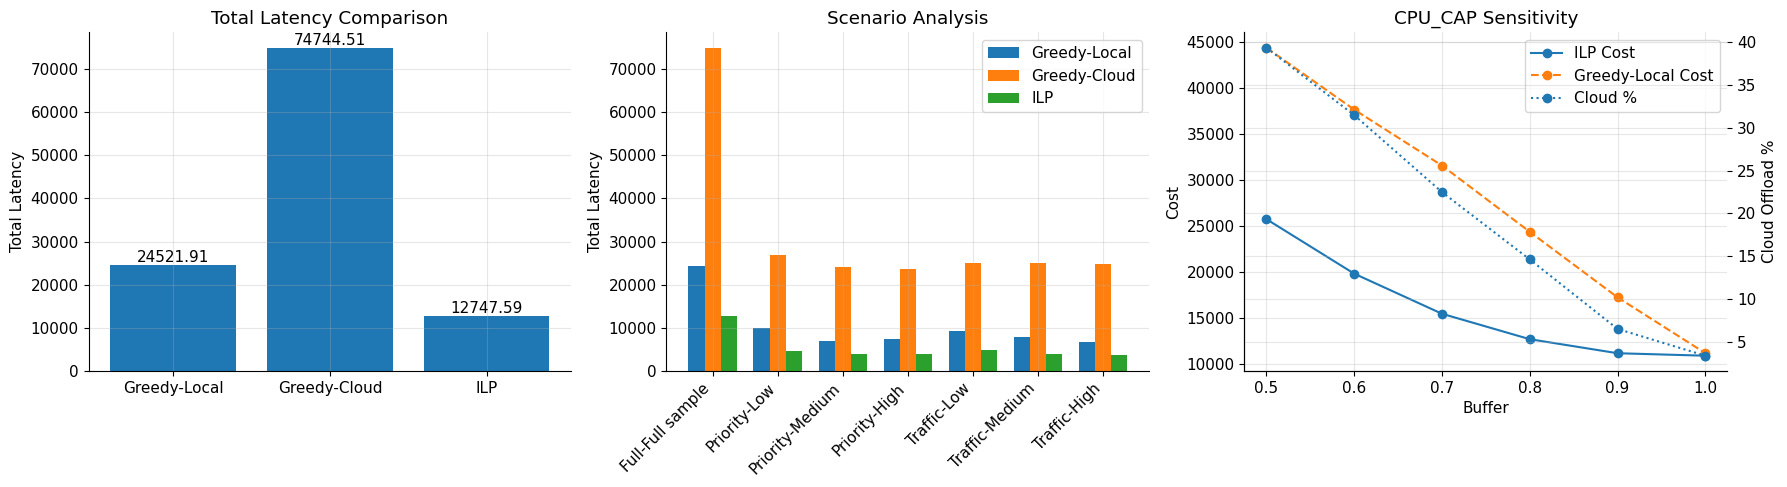

In [12]:
# =========================
# VISUALIZATION — 1x3 FIGURE
# =========================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# Plot 1: Total Latency Comparison
# -------------------------
ax1 = axes[0]

methods = ["Greedy-Local", "Greedy-Cloud", "ILP"]
values = [greedy_local, greedy_cloud, ilp_cost]

bars = ax1.bar(methods, values)

# Label each bar with value
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

ax1.set_title("Total Latency Comparison")
ax1.set_ylabel("Total Latency")


# -------------------------
# Plot 2: Scenario Analysis (Grouped Bar)
# -------------------------
ax2 = axes[1]

# Create scenario labels
scen_labels = scen_df["ScenarioType"] + "-" + scen_df["Scenario"]

x = np.arange(len(scen_df))
width = 0.25

bars1 = ax2.bar(x - width, scen_df["greedy_local"], width, label="Greedy-Local")
bars2 = ax2.bar(x, scen_df["greedy_cloud"], width, label="Greedy-Cloud")
bars3 = ax2.bar(x + width, scen_df["ILP"], width, label="ILP")

ax2.set_xticks(x)
ax2.set_xticklabels(scen_labels, rotation=45, ha='right')
ax2.set_title("Scenario Analysis")
ax2.set_ylabel("Total Latency")
ax2.legend()


# -------------------------
# Plot 3: CPU_CAP Sensitivity (Dual Axis)
# -------------------------
ax3 = axes[2]
ax3_r = ax3.twinx()

x = sens_df["buffer"]

# Left axis: costs
line1, = ax3.plot(x, sens_df["ILP"], marker='o', label="ILP Cost")
line2, = ax3.plot(x, sens_df["greedy_local"], marker='o', linestyle='--', label="Greedy-Local Cost")

# Right axis: cloud %
line3, = ax3_r.plot(x, sens_df["cloud_%"], marker='o', linestyle=':', label="Cloud %")

ax3.set_xlabel("Buffer")
ax3.set_ylabel("Cost")
ax3_r.set_ylabel("Cloud Offload %")

ax3.set_title("CPU_CAP Sensitivity")

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='best')


plt.tight_layout()
plt.show()

In [13]:
# =========================
# PARAMETERS — MODEL 2 (COST MINIMIZATION)
# =========================

# One-time hardware CapEx (SGD)
HARDWARE_COST_SGD = 5000

# Vehicle / hardware lifetime for amortisation
VEHICLE_LIFETIME_YRS = 10

# Number of tasks expected per day
TASKS_PER_DAY = 800

# Cloud pricing parameters
P_NET_PER_UNIT = 0.001          # SGD per transferred task-size unit
P_CLOUD_CPU_PER_UNIT = 0.001    # SGD per task-size compute unit

# Latency SLA by priority level (ms)
LATENCY_SLA = {
    "High": 80,
    "Medium": 120,
    "Low": 200
}

# Base local CPU commitment ratio
BUFFER_BASE = 0.8

# Number of sampled tasks per run
N = 800


# =========================
# DERIVED VALUES
# =========================

# Hardware lifetime in days
LIFETIME_DAYS = VEHICLE_LIFETIME_YRS * 365

# Daily amortised hardware cost
DAILY_CAPEX_BASE = HARDWARE_COST_SGD / LIFETIME_DAYS

# Number of force-local tasks in the full dataset
N_FORCE_LOCAL = int((df["force_local"] == 1).sum())

# Maximum allowed SLA violations
# Based on 20% of the expected force-local share within TASKS_PER_DAY
MAX_VIOLATIONS = max(
    1,
    int(TASKS_PER_DAY * (N_FORCE_LOCAL / len(df)) * 0.20)
)

# Network congestion proxy:
# normalize NetworkLatency into [0, 1]
df["congestion"] = df["NetworkLatency"] / df["NetworkLatency"].max()

# Cloud marginal cost per task:
# transfer fee + cloud compute fee
df["c_net"] = (
    df["TaskSize"] * df["congestion"] * P_NET_PER_UNIT
    + df["TaskSize"] * P_CLOUD_CPU_PER_UNIT
)

# Cloud latency per task
df["latency_cloud"] = df["NetworkLatency"]

# Map TaskPriority to latency SLA limit
df["latency_limit"] = df["TaskPriority"].map(LATENCY_SLA)


# =========================
# PRINT ASSUMPTIONS
# =========================

print("=== MODEL 2 PARAMETERS ===")
print(f"HARDWARE_COST_SGD      = {HARDWARE_COST_SGD}")
print(f"VEHICLE_LIFETIME_YRS   = {VEHICLE_LIFETIME_YRS}")
print(f"TASKS_PER_DAY          = {TASKS_PER_DAY}")
print(f"P_NET_PER_UNIT         = {P_NET_PER_UNIT}")
print(f"P_CLOUD_CPU_PER_UNIT   = {P_CLOUD_CPU_PER_UNIT}")
print(f"LATENCY_SLA            = {LATENCY_SLA}")
print(f"BUFFER_BASE            = {BUFFER_BASE}")
print(f"N                      = {N}")
print()

print("=== DERIVED VALUES ===")
print(f"LIFETIME_DAYS          = {LIFETIME_DAYS}")
print(f"DAILY_CAPEX_BASE       = {DAILY_CAPEX_BASE:.6f} SGD/day")
print(f"N_FORCE_LOCAL          = {N_FORCE_LOCAL}")
print(f"MAX_VIOLATIONS         = {MAX_VIOLATIONS}")
print()

print("=== DERIVED COLUMN SUMMARY ===")
print(f"congestion range       = [{df['congestion'].min():.6f}, {df['congestion'].max():.6f}]")
print(f"c_net mean             = {df['c_net'].mean():.6f}")
print(f"c_net range            = [{df['c_net'].min():.6f}, {df['c_net'].max():.6f}]")
print(f"latency_cloud mean     = {df['latency_cloud'].mean():.4f}")
print(f"latency_cloud range    = [{df['latency_cloud'].min():.4f}, {df['latency_cloud'].max():.4f}]")
print(f"latency_limit values   = {sorted(df['latency_limit'].dropna().unique().tolist())}")

=== MODEL 2 PARAMETERS ===
HARDWARE_COST_SGD      = 5000
VEHICLE_LIFETIME_YRS   = 10
TASKS_PER_DAY          = 800
P_NET_PER_UNIT         = 0.001
P_CLOUD_CPU_PER_UNIT   = 0.001
LATENCY_SLA            = {'High': 80, 'Medium': 120, 'Low': 200}
BUFFER_BASE            = 0.8
N                      = 800

=== DERIVED VALUES ===
LIFETIME_DAYS          = 3650
DAILY_CAPEX_BASE       = 1.369863 SGD/day
N_FORCE_LOCAL          = 944
MAX_VIOLATIONS         = 17

=== DERIVED COLUMN SUMMARY ===
congestion range       = [0.050040, 1.000000]
c_net mean             = 0.008357
c_net range            = [0.001114, 0.019688]
latency_cloud mean     = 104.2361
latency_cloud range    = [10.0055, 199.9503]
latency_limit values   = [80, 120, 200]


In [14]:
# =========================
# HELPER FUNCTIONS — MODEL 2
# =========================

import pandas as pd
import gurobipy as gp
from gurobipy import GRB


def compute_latency_local(df_s: pd.DataFrame, cpu_cap: float, cpu_cap_base: float) -> pd.Series:
    """
    Compute local execution latency under a scaled CPU capacity.

    Base local latency proxy:
        base_i = TaskSize_i / (CPU_Available_i / 100)

    Adjusted local latency:
        lat_loc_i = base_i * (cpu_cap_base / cpu_cap)

    Interpretation:
    - If cpu_cap < cpu_cap_base, local latency increases.
    - If cpu_cap > cpu_cap_base, local latency decreases.

    Parameters
    ----------
    df_s : pd.DataFrame
        Input task dataframe containing 'TaskSize' and 'CPU_Available'.
    cpu_cap : float
        Actual local CPU capacity used in this run.
    cpu_cap_base : float
        Baseline local CPU capacity used as reference.

    Returns
    -------
    pd.Series
        Local latency for each task.
    """
    required_cols = ["TaskSize", "CPU_Available"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if cpu_cap <= 0 or cpu_cap_base <= 0:
        raise ValueError("cpu_cap and cpu_cap_base must be positive.")

    base = df_s["TaskSize"] / (df_s["CPU_Available"] / 100.0)
    return base * (cpu_cap_base / cpu_cap)


def solve_cost_ilp(
    df_s: pd.DataFrame,
    cpu_cap: float,
    cpu_cap_base: float,
    buffer: float,
    max_violations: int | None = None,
    label: str = "ILP"
) -> dict:
    """
    Solve Model 2 cost-minimization ILP.

    Decision variables
    ------------------
    x[i] = 1 if task i is offloaded to cloud, else 0
    v[i] = 1 if task i violates latency SLA, else 0

    Objective
    ---------
    Minimize cloud OpEx only:
        sum(x[i] * c_net[i])

    Constant daily CapEx is added after optimization:
        capex = DAILY_CAPEX_BASE * buffer

    Constraints
    -----------
    C1: x[i] <= 1 - force_local[i]
    C2: sum((1 - x[i]) * TaskSize[i]) <= cpu_cap
    C3: (1-x[i]) * lat_loc[i] + x[i] * lat_cld[i] <= lat_lim[i] + BIG_M * v[i]
    C4: sum(v[i]) <= max_violations

    Parameters
    ----------
    df_s : pd.DataFrame
        Task dataframe with columns:
        'task_id', 'TaskSize', 'force_local', 'c_net',
        'latency_cloud', 'latency_limit', 'CPU_Available'
    cpu_cap : float
        Actual local CPU capacity.
    cpu_cap_base : float
        Baseline local CPU capacity for latency scaling.
    buffer : float
        Buffer factor used to scale daily CapEx.
    max_violations : int or None, default=None
        If provided, overrides global MAX_VIOLATIONS.
    label : str, default="ILP"
        Model name.

    Returns
    -------
    dict
        {
            "status": solver_status_code,
            "actual_cost": capex + opex or None,
            "capex": capex or None,
            "opex": opex or None,
            "actual_latency": total realized latency or None,
            "cloud_count": number of cloud tasks or None,
            "violations": number of SLA violations or None,
            "decisions": list of 0/1 cloud decisions or None
        }
    """
    required_cols = [
        "task_id", "TaskSize", "force_local", "c_net",
        "latency_cloud", "latency_limit", "CPU_Available"
    ]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if cpu_cap <= 0 or cpu_cap_base <= 0:
        raise ValueError("cpu_cap and cpu_cap_base must be positive.")

    viol_cap = MAX_VIOLATIONS if max_violations is None else max_violations

    # Precompute local latency under this capacity setting
    df_model = df_s.copy()
    df_model["lat_loc"] = compute_latency_local(df_model, cpu_cap=cpu_cap, cpu_cap_base=cpu_cap_base)

    # Big-M chosen from observed latency scales
    max_lat = max(
        float(df_model["lat_loc"].max()),
        float(df_model["latency_cloud"].max()),
        float(df_model["latency_limit"].max())
    )
    BIG_M = max(1e4, 10 * max_lat)

    # Build lookup dictionaries indexed by task_id
    tasks = df_model["task_id"].tolist()
    task_size = df_model.set_index("task_id")["TaskSize"].to_dict()
    force_local = df_model.set_index("task_id")["force_local"].to_dict()
    c_net = df_model.set_index("task_id")["c_net"].to_dict()
    lat_loc = df_model.set_index("task_id")["lat_loc"].to_dict()
    lat_cld = df_model.set_index("task_id")["latency_cloud"].to_dict()
    lat_lim = df_model.set_index("task_id")["latency_limit"].to_dict()

    model = gp.Model(label)
    model.setParam("OutputFlag", 0)

    # x[i] = 1 => cloud, 0 => local
    x = model.addVars(tasks, vtype=GRB.BINARY, name="x")

    # v[i] = 1 => SLA violation
    v = model.addVars(tasks, vtype=GRB.BINARY, name="v")

    # Objective: minimize variable cloud OpEx only
    model.setObjective(
        gp.quicksum(x[i] * c_net[i] for i in tasks),
        GRB.MINIMIZE
    )

    # C1: forced-local tasks cannot be offloaded
    model.addConstrs(
        (x[i] <= 1 - force_local[i] for i in tasks),
        name="force_local"
    )

    # C2: total local task size within local capacity
    model.addConstr(
        gp.quicksum((1 - x[i]) * task_size[i] for i in tasks) <= cpu_cap,
        name="cpu_cap"
    )

    # C3: latency SLA with violation slack
    model.addConstrs(
        (
            (1 - x[i]) * lat_loc[i] + x[i] * lat_cld[i]
            <= lat_lim[i] + BIG_M * v[i]
            for i in tasks
        ),
        name="latency_sla"
    )

    # C4: cap number of violations
    model.addConstr(
        gp.quicksum(v[i] for i in tasks) <= viol_cap,
        name="violation_cap"
    )

    model.optimize()

    result = {
        "status": model.Status,
        "actual_cost": None,
        "capex": None,
        "opex": None,
        "actual_latency": None,
        "cloud_count": None,
        "violations": None,
        "decisions": None,
    }

    if model.SolCount > 0:
        decisions = [int(round(x[i].X)) for i in tasks]
        violation_flags = [int(round(v[i].X)) for i in tasks]

        opex = float(model.ObjVal)
        capex = float(DAILY_CAPEX_BASE * buffer)
        actual_cost = capex + opex
        cloud_count = int(sum(decisions))
        violations = int(sum(violation_flags))

        # Realized total latency from chosen assignments
        actual_latency = float(
            sum((1 - decisions[k]) * lat_loc[tasks[k]] + decisions[k] * lat_cld[tasks[k]]
                for k in range(len(tasks)))
        )

        result.update({
            "actual_cost": actual_cost,
            "capex": capex,
            "opex": opex,
            "actual_latency": actual_latency,
            "cloud_count": cloud_count,
            "violations": violations,
            "decisions": decisions,
        })

    return result


def baseline_greedy_local(
    df_s: pd.DataFrame,
    cpu_cap: float,
    cpu_cap_base: float,
    buffer: float
) -> float:
    """
    Greedy baseline for Model 2.

    Policy
    ------
    - Local first because local has zero marginal OpEx
    - If force_local == 1, keep local
    - Else keep local while capacity remains
    - Overflow tasks go to cloud and incur c_net

    Total cost returned:
        daily capex + total cloud opex

    Parameters
    ----------
    df_s : pd.DataFrame
        Task dataframe containing 'TaskSize', 'force_local', 'c_net'.
    cpu_cap : float
        Actual local CPU capacity.
    cpu_cap_base : float
        Baseline CPU capacity. Included for interface consistency.
    buffer : float
        Buffer factor used to scale daily CapEx.

    Returns
    -------
    float
        Total daily cost = capex + cloud opex.
    """
    required_cols = ["TaskSize", "force_local", "c_net"]
    missing = [c for c in required_cols if c not in df_s.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    local_used = 0.0
    cloud_opex = 0.0

    for _, row in df_s.iterrows():
        if int(row["force_local"]) == 1:
            local_used += row["TaskSize"]
        elif local_used + row["TaskSize"] <= cpu_cap:
            local_used += row["TaskSize"]
        else:
            cloud_opex += row["c_net"]

    capex = DAILY_CAPEX_BASE * buffer
    return float(capex + cloud_opex)


def find_feasible_cap(
    df_s: pd.DataFrame,
    cpu_cap_base: float,
    buffer: float,
    label: str
):
    """
    Search for a feasible CPU capacity by scaling the base capacity.

    Tries multipliers:
        [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]

    For each multiplier m:
        cpu_cap = cpu_cap_base * m
        solve Model 2 ILP
    Stops at the first feasible solution.

    Parameters
    ----------
    df_s : pd.DataFrame
        Task dataframe for optimization.
    cpu_cap_base : float
        Baseline CPU capacity before scaling.
    buffer : float
        Buffer factor for CapEx scaling.
    label : str
        Base model label.

    Returns
    -------
    tuple
        (result, cap_used, multiplier)

        If no feasible solution is found:
        (None, None, None)
    """
    multipliers = [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]

    for m in multipliers:
        cap_used = cpu_cap_base * m
        result = solve_cost_ilp(
            df_s=df_s,
            cpu_cap=cap_used,
            cpu_cap_base=cpu_cap_base,
            buffer=buffer,
            max_violations=None,
            label=f"{label}_x{m}"
        )

        if result["status"] == GRB.OPTIMAL:
            return result, cap_used, m

    return None, None, None

In [15]:
# =========================
# CELL 1 — MAIN RUN (MODEL 2)
# =========================

# Sample tasks
df_s2 = sample_tasks(df, n=N, seed=SEED)

# Baseline CPU capacity at the base buffer
CPU_CAP_BASE = compute_cpu_cap(df, buffer=BUFFER_BASE, n=N)

# Solve using feasibility search
ilp2_res, cap_used, cap_multiplier = find_feasible_cap(
    df_s=df_s2,
    cpu_cap_base=CPU_CAP_BASE,
    buffer=BUFFER_BASE,
    label="Model2_MainRun"
)

# Greedy-Local baseline under the same capacity actually used by the ILP
# If no feasible ILP is found, fall back to the base capacity
cpu_cap_eval = cap_used if cap_used is not None else CPU_CAP_BASE

greedy_total = baseline_greedy_local(
    df_s=df_s2,
    cpu_cap=cpu_cap_eval,
    cpu_cap_base=CPU_CAP_BASE,
    buffer=BUFFER_BASE
)

# Split greedy baseline into CapEx and OpEx for reporting
greedy_capex = DAILY_CAPEX_BASE * BUFFER_BASE
greedy_opex = greedy_total - greedy_capex

# Prepare ILP metrics
if ilp2_res is not None:
    ilp_capex = ilp2_res["capex"]
    ilp_opex = ilp2_res["opex"]
    ilp_total = ilp2_res["actual_cost"]
    ilp_cloud = ilp2_res["cloud_count"]
    ilp_local = len(df_s2) - ilp_cloud
    ilp_viol = ilp2_res["violations"]
    ilp_latency = ilp2_res["actual_latency"]
else:
    ilp_capex = None
    ilp_opex = None
    ilp_total = None
    ilp_cloud = None
    ilp_local = None
    ilp_viol = None
    ilp_latency = None

# Savings vs Greedy-Local
vs_greedy_local_greedy = 0.0
vs_greedy_local_ilp = (
    100 * (greedy_total - ilp_total) / greedy_total
    if greedy_total != 0 and ilp_total is not None else None
)

main2_df = pd.DataFrame({
    "Strategy": ["Greedy-Local", "ILP"],
    "CapEx/day": [greedy_capex, ilp_capex],
    "OpEx/day": [greedy_opex, ilp_opex],
    "Total/day": [greedy_total, ilp_total],
    "vs Greedy-Local %": [vs_greedy_local_greedy, vs_greedy_local_ilp],
})

print("=== MODEL 2 — MAIN RUN ===")
print(f"Sample size: {len(df_s2)}")
print(f"CPU_CAP_BASE: {CPU_CAP_BASE:.4f}")
print(f"CPU_CAP used: {cpu_cap_eval:.4f}")
print(f"Capacity multiplier used: {cap_multiplier if cap_multiplier is not None else 'NA'}")
print()
print(main2_df.to_string(index=False, float_format=lambda x: f"{x:.6f}" if pd.notnull(x) else "NA"))
print()

if ilp2_res is not None:
    print(f"ILP assignment: {ilp_local} local / {ilp_cloud} cloud")
    print(f"SLA violations: {ilp_viol}")
    print(f"Total latency: {ilp_latency:.4f}")
else:
    print("No feasible ILP solution found under tested capacity multipliers.")

=== MODEL 2 — MAIN RUN ===
Sample size: 800
CPU_CAP_BASE: 3500.3848
CPU_CAP used: 3500.3848
Capacity multiplier used: 1.0

    Strategy  CapEx/day  OpEx/day  Total/day  vs Greedy-Local %
Greedy-Local   1.095890  1.161586   2.257477           0.000000
         ILP   1.095890  0.977318   2.073208           8.162575

ILP assignment: 641 local / 159 cloud
SLA violations: 1
Total latency: 14109.9637


In [16]:
# =========================
# CELL 2 — SCENARIO ANALYSIS (MODEL 2)
# =========================

# Reuse the same sampled tasks from Cell 1
df_scen2 = df_s2.copy()

# Create scenario buckets
df_scen2["PriorityGroup"] = _bucket_priority(df_scen2["TaskPriority"])
df_scen2["TrafficGroup"] = _bucket_traffic(df_scen2["TrafficDensity"])

scenario_rows2 = []

def _run_model2_scenario(sub_df: pd.DataFrame, scenario_type: str, scenario_name: str):
    """
    Run greedy and ILP for one Model 2 scenario and append results.
    """
    if len(sub_df) == 0:
        return

    cpu_cap_base_sub = compute_cpu_cap(sub_df, buffer=BUFFER_BASE, n=len(sub_df))

    # Scale allowed violations proportionally to scenario size
    max_viol_sub = max(1, int(MAX_VIOLATIONS * len(sub_df) / N))

    # Feasibility search with scenario-specific violation cap
    multipliers = [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
    best_res = None
    best_cap = None
    best_mult = None

    for m in multipliers:
        cap_try = cpu_cap_base_sub * m
        res_try = solve_cost_ilp(
            df_s=sub_df,
            cpu_cap=cap_try,
            cpu_cap_base=cpu_cap_base_sub,
            buffer=BUFFER_BASE,
            max_violations=max_viol_sub,
            label=f"Model2_{scenario_type}_{scenario_name}_x{m}"
        )
        if res_try["status"] == GRB.OPTIMAL:
            best_res = res_try
            best_cap = cap_try
            best_mult = m
            break

    # If nothing is optimal, still keep the last result if any solution exists
    if best_res is None:
        best_res = res_try if 'res_try' in locals() else None
        best_cap = cap_try if 'cap_try' in locals() else None
        best_mult = m if 'm' in locals() else None

    # Greedy under the same evaluated capacity
    greedy_total_sub = baseline_greedy_local(
        df_s=sub_df,
        cpu_cap=best_cap if best_cap is not None else cpu_cap_base_sub,
        cpu_cap_base=cpu_cap_base_sub,
        buffer=BUFFER_BASE
    )
    greedy_capex_sub = DAILY_CAPEX_BASE * BUFFER_BASE
    greedy_opex_sub = greedy_total_sub - greedy_capex_sub

    if best_res is not None and best_res["actual_cost"] is not None:
        ilp_total_sub = best_res["actual_cost"]
        ilp_capex_sub = best_res["capex"]
        ilp_opex_sub = best_res["opex"]
        ilp_cloud_sub = best_res["cloud_count"]
        ilp_cloud_pct_sub = 100 * ilp_cloud_sub / len(sub_df) if len(sub_df) > 0 else None
        saved_pct_sub = 100 * (greedy_total_sub - ilp_total_sub) / greedy_total_sub if greedy_total_sub != 0 else None
        ilp_viol_sub = best_res["violations"]
        ilp_latency_sub = best_res["actual_latency"]
    else:
        ilp_total_sub = None
        ilp_capex_sub = None
        ilp_opex_sub = None
        ilp_cloud_sub = None
        ilp_cloud_pct_sub = None
        saved_pct_sub = None
        ilp_viol_sub = None
        ilp_latency_sub = None

    scenario_rows2.append({
        "ScenarioType": scenario_type,
        "Scenario": scenario_name,
        "n_tasks": len(sub_df),
        "cpu_cap_base": cpu_cap_base_sub,
        "cpu_cap_used": best_cap,
        "cap_multiplier": best_mult,
        "greedy_capex": greedy_capex_sub,
        "greedy_opex": greedy_opex_sub,
        "greedy_total": greedy_total_sub,
        "ILP_capex": ilp_capex_sub,
        "ILP_opex": ilp_opex_sub,
        "ILP_total": ilp_total_sub,
        "saved_%": saved_pct_sub,
        "cloud_%": ilp_cloud_pct_sub,
        "violations": ilp_viol_sub,
        "total_latency": ilp_latency_sub,
    })


# Full sample
_run_model2_scenario(df_scen2, "Full", "Full sample")

# Priority scenarios
for level in ["Low", "Medium", "High"]:
    sub = df_scen2[df_scen2["PriorityGroup"] == level].copy()
    _run_model2_scenario(sub, "Priority", level)

# Traffic scenarios
for level in ["Low", "Medium", "High"]:
    sub = df_scen2[df_scen2["TrafficGroup"] == level].copy()
    _run_model2_scenario(sub, "Traffic", level)

# Store results
scen_df2 = pd.DataFrame(scenario_rows2)

print("=== MODEL 2 — SCENARIO ANALYSIS ===")
print(
    scen_df2[
        [
            "ScenarioType", "Scenario", "n_tasks",
            "greedy_capex", "greedy_opex", "greedy_total",
            "ILP_capex", "ILP_opex", "ILP_total",
            "saved_%", "cloud_%"
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.6f}" if pd.notnull(x) else "NA")
)

=== MODEL 2 — SCENARIO ANALYSIS ===
ScenarioType    Scenario  n_tasks  greedy_capex  greedy_opex  greedy_total  ILP_capex  ILP_opex  ILP_total  saved_%   cloud_%
        Full Full sample      800      1.095890     1.135423      2.231313   1.095890  0.955629   2.051519 8.057745 19.500000
    Priority         Low      268      1.095890     0.542627      1.638518   1.095890  0.402851   1.498742 8.530622 21.268657
    Priority      Medium      262      1.095890     0.342386      1.438276   1.095890  0.302269   1.398159 2.789233 19.847328
    Priority        High      270      1.095890     0.269906      1.365796   1.095890  0.251709   1.347600 1.332322 15.925926
     Traffic         Low      274      1.095890     0.490912      1.586802   1.095890  0.416763   1.512653 4.672869 24.817518
     Traffic      Medium      272      1.095890     0.380636      1.476527   1.095890  0.318508   1.414399 4.207722 17.279412
     Traffic        High      254      1.095890     0.276660      1.372550   1.095


SECTION 12 — Sensitivity: Local Latency vs Daily Cost
Lower buffer => higher local latency => more cloud offload => higher OpEx
  buffer=0.7  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=1.5490  total=2.5079  cloud=29%  saved=6.8%
  buffer=0.8  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=0.9773  total=2.0732  cloud=20%  saved=8.2%
  buffer=0.9  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=0.4472  total=1.6800  cloud=10%  saved=6.0%
  buffer=1.0  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=0.0000  total=1.3699  cloud=0%  saved=0.0%
  buffer=1.1  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=0.0000  total=1.5068  cloud=0%  saved=0.0%
  buffer=1.2  lat_local=13.9ms  local_exceed=1  both_exceed=1  viol_budget=17  actual_viol=1  opex=0.0000  total=1.6438  cloud=0%  saved=0.0%

  Insight: as b

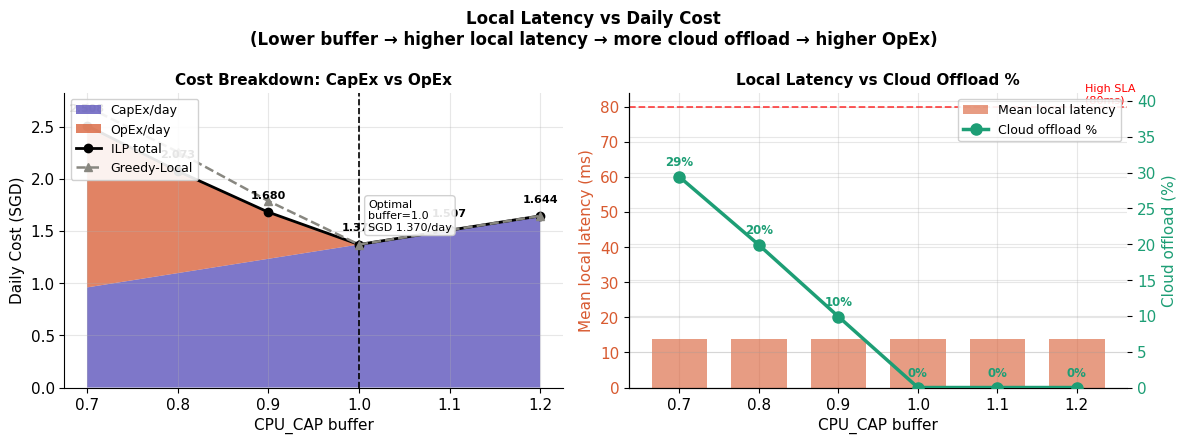

  Saved: fig_sla_latency_sensitivity.png


In [24]:
# =============================================================================
# SECTION 12 — SENSITIVITY: LOCAL LATENCY vs DAILY COST
# =============================================================================
#
# Lower buffer => higher local latency => more tasks pushed to cloud by C3
# => higher OpEx. MAX_VIOLATIONS scales dynamically with buffer to prevent
# infeasibility at low buffer levels.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "=" * 60)
print("SECTION 12 — Sensitivity: Local Latency vs Daily Cost")
print("=" * 60)
print("Lower buffer => higher local latency => more cloud offload => higher OpEx")

buffers_sla = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
sla_rows = []

# Use one sampled dataset for the whole section
df_sec12 = sample_tasks(df, n=N, seed=SEED).copy()

for buffer in buffers_sla:
    # Capacity under this buffer
    cpu_cap = compute_cpu_cap(df, buffer=buffer, n=N)
    cpu_cap_base = cpu_cap

    # Local latency under this capacity
    lat_local = compute_latency_local(
        df_sec12,
        cpu_cap=cpu_cap,
        cpu_cap_base=cpu_cap_base
    )

    # Count local-only feasibility pressure
    n_local_exceed = int((lat_local > df_sec12["latency_limit"]).sum())
    n_both_exceed = int(
        (
            (lat_local > df_sec12["latency_limit"]) &
            (df_sec12["latency_cloud"] > df_sec12["latency_limit"])
        ).sum()
    )

    # Dynamic violation budget
    dynamic_viol = max(MAX_VIOLATIONS, n_both_exceed, int(n_local_exceed * 0.20))

    # Solve ILP with dynamic violation budget
    res = solve_cost_ilp(
        df_s=df_sec12,
        cpu_cap=cpu_cap,
        cpu_cap_base=cpu_cap_base,
        buffer=buffer,
        max_violations=dynamic_viol,
        label=f"Sec12_buf_{buffer:.1f}"
    )

    # Greedy baseline under same capacity/buffer
    greedy_total = baseline_greedy_local(
        df_s=df_sec12,
        cpu_cap=cpu_cap,
        cpu_cap_base=cpu_cap_base,
        buffer=buffer
    )

    # Handle infeasible / failed cases cleanly
    if res["actual_cost"] is None:
        print(
            f"  buffer={buffer:.1f}  lat_local={lat_local.mean():.1f}ms  "
            f"local_exceed={n_local_exceed}  both_exceed={n_both_exceed} : INFEASIBLE"
        )
        continue

    greedy_capex = DAILY_CAPEX_BASE * buffer
    greedy_opex = greedy_total - greedy_capex

    saved_pct = 100 * (greedy_total - res["actual_cost"]) / greedy_total if greedy_total != 0 else None
    cloud_pct = 100 * res["cloud_count"] / len(df_sec12) if len(df_sec12) > 0 else None

    sla_rows.append({
        "buffer": buffer,
        "cpu_cap": cpu_cap,
        "lat_local_mean": round(float(lat_local.mean()), 1),
        "n_local_exceed": n_local_exceed,
        "n_both_exceed": n_both_exceed,
        "viol_budget": dynamic_viol,
        "actual_viol": res["violations"],
        "capex": round(res["capex"], 4),
        "opex": round(res["opex"], 6),
        "ilp_total": round(res["actual_cost"], 6),      # renamed for plotting style
        "greedy_local": round(greedy_total, 6),         # renamed for plotting style
        "cloud_pct": round(cloud_pct, 1) if cloud_pct is not None else None,
        "save_pct": round(saved_pct, 1) if saved_pct is not None else None,
    })

    print(
        f"  buffer={buffer:.1f}  lat_local={lat_local.mean():.1f}ms  "
        f"local_exceed={n_local_exceed}  both_exceed={n_both_exceed}  "
        f"viol_budget={dynamic_viol}  actual_viol={res['violations']}  "
        f"opex={res['opex']:.4f}  total={res['actual_cost']:.4f}  "
        f"cloud={cloud_pct:.0f}%  saved={saved_pct:.1f}%"
    )

sla_df = pd.DataFrame(sla_rows)

if len(sla_df) > 0:
    print(
        f"\n  Insight: as buffer drops from {sla_df['buffer'].max()} "
        f"to {sla_df['buffer'].min()}, "
        f"OpEx rises from SGD {sla_df.loc[sla_df['buffer'].idxmax(), 'opex']:.4f} "
        f"to SGD {sla_df.loc[sla_df['buffer'].idxmin(), 'opex']:.4f}/day"
    )

# ── Section 12 Figure ─────────────────────────────────────────────────────────
if len(sla_df) > 0:
    C_ILP   = "#1D9E75"
    C_LOCAL = "#888780"
    C_CAPEX = "#534AB7"
    C_OPEX  = "#D85A30"

    fig_sla, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))
    fig_sla.suptitle(
        "Local Latency vs Daily Cost\n"
        "(Lower buffer → higher local latency → more cloud offload → higher OpEx)",
        fontsize=12, fontweight="bold"
    )

    # Left: stacked area
    ax_l.stackplot(
        sla_df["buffer"],
        sla_df["capex"],
        sla_df["opex"],
        labels=["CapEx/day", "OpEx/day"],
        colors=[C_CAPEX, C_OPEX],
        alpha=0.75
    )
    ax_l.plot(
        sla_df["buffer"], sla_df["ilp_total"],
        color="black", linewidth=2, marker="o",
        markersize=6, label="ILP total", zorder=3
    )
    ax_l.plot(
        sla_df["buffer"], sla_df["greedy_local"],
        color=C_LOCAL, linewidth=1.8, marker="^",
        markersize=6, linestyle="--", label="Greedy-Local", zorder=3
    )

    for _, row in sla_df.iterrows():
        ax_l.annotate(
            f"{row['ilp_total']:.3f}",
            xy=(row["buffer"], row["ilp_total"]),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=8, color="black",
            fontweight="bold"
        )

    # Mark optimal buffer
    best_idx = sla_df["ilp_total"].idxmin()
    best_buf = sla_df.loc[best_idx, "buffer"]
    best_tot = sla_df.loc[best_idx, "ilp_total"]
    ax_l.axvline(x=best_buf, color="black", linewidth=1.2, linestyle="--")
    ax_l.text(
        best_buf + 0.01, best_tot * 1.1,
        f"Optimal\nbuffer={best_buf}\nSGD {best_tot:.3f}/day",
        fontsize=8, color="black",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.9
        )
    )

    ax_l.set_xlabel("CPU_CAP buffer", fontsize=11)
    ax_l.set_ylabel("Daily Cost (SGD)", fontsize=11)
    ax_l.set_title("Cost Breakdown: CapEx vs OpEx", fontsize=11, fontweight="bold")
    ax_l.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax_l.set_xticks(sla_df["buffer"])

    # Right: latency bars + cloud % line
    ax_r2 = ax_r.twinx()
    ax_r.bar(
        sla_df["buffer"], sla_df["lat_local_mean"],
        color=C_OPEX, width=0.07, alpha=0.6,
        label="Mean local latency", zorder=2
    )
    ax_r2.plot(
        sla_df["buffer"], sla_df["cloud_pct"],
        color=C_ILP, linewidth=2.5, marker="o",
        markersize=8, label="Cloud offload %", zorder=3
    )

    # Optional SLA line if LATENCY_SLA exists
    try:
        high_sla = LATENCY_SLA["High"]
        ax_r.axhline(y=high_sla, color="red", linewidth=1.3,
                     linestyle="--", alpha=0.7)
        ax_r.text(
            sla_df["buffer"].max() + 0.01, high_sla + 0.5,
            f"High SLA\n({high_sla}ms)",
            color="red", fontsize=8, va="bottom"
        )
    except Exception:
        pass

    for _, row in sla_df.iterrows():
        ax_r2.annotate(
            f"{row['cloud_pct']:.0f}%",
            xy=(row["buffer"], row["cloud_pct"]),
            xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=8.5, color=C_ILP,
            fontweight="bold"
        )

    ax_r.set_xlabel("CPU_CAP buffer", fontsize=11)
    ax_r.set_ylabel("Mean local latency (ms)", fontsize=11, color=C_OPEX)
    ax_r.tick_params(axis="y", labelcolor=C_OPEX)
    ax_r2.set_ylabel("Cloud offload (%)", fontsize=11, color=C_ILP)
    ax_r2.tick_params(axis="y", labelcolor=C_ILP)

    ymax = sla_df["cloud_pct"].max()
    ax_r2.set_ylim(0, ymax * 1.4 if ymax > 0 else 1)

    ax_r.set_title("Local Latency vs Cloud Offload %", fontsize=11, fontweight="bold")
    ax_r.set_xticks(sla_df["buffer"])

    lines1, labels1 = ax_r.get_legend_handles_labels()
    lines2, labels2 = ax_r2.get_legend_handles_labels()
    ax_r.legend(
        lines1 + lines2, labels1 + labels2,
        fontsize=9, loc="upper right", framealpha=0.9
    )

    fig_sla.tight_layout()
    fig_sla.savefig("fig_sla_latency_sensitivity.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("  Saved: fig_sla_latency_sensitivity.png")

In [18]:
# =========================
# CELL 2 — SECTION 13: CPU_CAP BUFFER vs DAILY COST
# =========================

buffers_cap = [round(x, 1) for x in np.arange(0.1, 1.01, 0.1)] + [1.2, 1.5, 2.0]
cap_rows = []

# Use one sampled dataset for the whole section
df_sec13 = sample_tasks(df, n=N, seed=SEED).copy()

print("=== SECTION 13: CPU_CAP BUFFER vs DAILY COST ===")

for buffer in buffers_cap:
    cpu_cap = compute_cpu_cap(df, buffer=buffer, n=N)
    cpu_cap_base = cpu_cap

    lat_local = compute_latency_local(df_sec13, cpu_cap=cpu_cap, cpu_cap_base=cpu_cap_base)

    res = solve_cost_ilp(
        df_s=df_sec13,
        cpu_cap=cpu_cap,
        cpu_cap_base=cpu_cap_base,
        buffer=buffer,
        max_violations=MAX_VIOLATIONS,   # fixed global violation budget
        label=f"Sec13_buf_{buffer:.1f}"
    )

    greedy_total = baseline_greedy_local(
        df_s=df_sec13,
        cpu_cap=cpu_cap,
        cpu_cap_base=cpu_cap_base,
        buffer=buffer
    )

    if res["actual_cost"] is None:
        print(
            f"buffer={buffer:.1f} | INFEASIBLE | "
            f"lat_local_mean={lat_local.mean():.6f}, "
            f"lat_local_max={lat_local.max():.6f}"
        )
        cap_rows.append({
            "buffer": buffer,
            "cpu_cap": cpu_cap,
            "lat_local_mean": float(lat_local.mean()),
            "lat_local_max": float(lat_local.max()),
            "feasible": False,
            "capex": None,
            "opex": None,
            "total": None,
            "greedy": greedy_total,
            "cloud_%": None,
            "saved_%": None,
            "violations": None,
        })
        continue

    cloud_pct = 100 * res["cloud_count"] / len(df_sec13) if len(df_sec13) > 0 else None
    saved_pct = 100 * (greedy_total - res["actual_cost"]) / greedy_total if greedy_total != 0 else None

    print(
        f"buffer={buffer:.1f} | "
        f"capex={res['capex']:.6f} | "
        f"opex={res['opex']:.6f} | "
        f"total={res['actual_cost']:.6f} | "
        f"greedy={greedy_total:.6f} | "
        f"cloud%={cloud_pct:.4f} | "
        f"saved%={saved_pct:.4f}"
    )

    cap_rows.append({
        "buffer": buffer,
        "cpu_cap": cpu_cap,
        "lat_local_mean": float(lat_local.mean()),
        "lat_local_max": float(lat_local.max()),
        "feasible": True,
        "capex": res["capex"],
        "opex": res["opex"],
        "total": res["actual_cost"],
        "greedy": greedy_total,
        "cloud_%": cloud_pct,
        "saved_%": saved_pct,
        "violations": res["violations"],
    })

cap_df2 = pd.DataFrame(cap_rows)

# Report optimal feasible buffer
feasible_cap_df2 = cap_df2[cap_df2["feasible"] == True].copy()

if len(feasible_cap_df2) > 0:
    best_idx = feasible_cap_df2["total"].idxmin()
    best_row = feasible_cap_df2.loc[best_idx]

    print()
    print("Optimal buffer:")
    print(f"buffer   = {best_row['buffer']:.4f}")
    print(f"cpu_cap  = {best_row['cpu_cap']:.6f}")
    print(f"capex    = {best_row['capex']:.6f}")
    print(f"opex     = {best_row['opex']:.6f}")
    print(f"total    = {best_row['total']:.6f}")
    print(f"greedy   = {best_row['greedy']:.6f}")
    print(f"cloud%   = {best_row['cloud_%']:.4f}")
    print(f"saved%   = {best_row['saved_%']:.4f}")
else:
    print()
    print("No feasible buffer found.")

=== SECTION 13: CPU_CAP BUFFER vs DAILY COST ===
buffer=0.1 | INFEASIBLE | lat_local_mean=13.929171, lat_local_max=85.491979
buffer=0.2 | INFEASIBLE | lat_local_mean=13.929171, lat_local_max=85.491979
buffer=0.3 | INFEASIBLE | lat_local_mean=13.929171, lat_local_max=85.491979
buffer=0.4 | capex=0.547945 | opex=3.609953 | total=4.157899 | greedy=4.041932 | cloud%=57.8750 | saved%=-2.8691
buffer=0.5 | capex=0.684932 | opex=2.833042 | total=3.517974 | greedy=3.590786 | cloud%=48.7500 | saved%=2.0278
buffer=0.6 | capex=0.821918 | opex=2.162987 | total=2.984905 | greedy=3.106210 | cloud%=39.0000 | saved%=3.9052
buffer=0.7 | capex=0.958904 | opex=1.548995 | total=2.507899 | greedy=2.690049 | cloud%=29.3750 | saved%=6.7713
buffer=0.8 | capex=1.095890 | opex=0.977318 | total=2.073208 | greedy=2.257477 | cloud%=19.8750 | saved%=8.1626
buffer=0.9 | capex=1.232877 | opex=0.447164 | total=1.680040 | greedy=1.786852 | cloud%=9.8750 | saved%=5.9776
buffer=1.0 | capex=1.369863 | opex=0.000000 | total

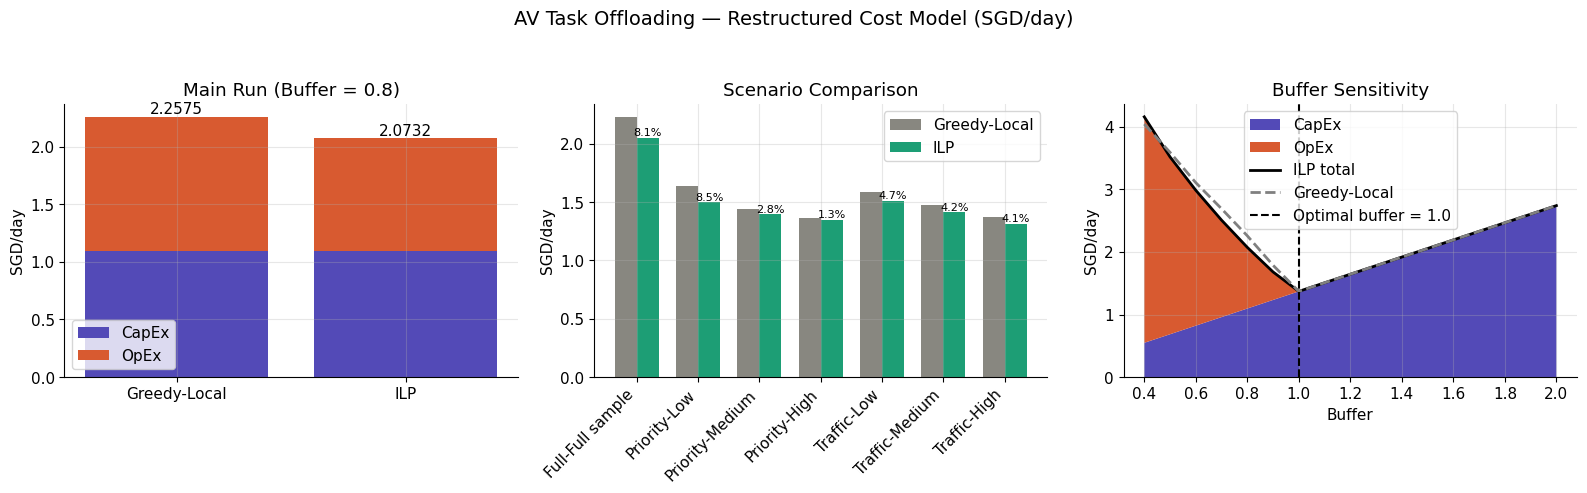

In [22]:
# =========================
# VISUALIZATION — MODEL 2 SUMMARY (BUFFER = 0.8)
# =========================

import matplotlib.pyplot as plt
import numpy as np

# ---------- Filter buffer = 0.8 from cap_df2 ----------
buf_target = 0.8
row_08 = cap_df2[(cap_df2["feasible"] == True) & (cap_df2["buffer"] == buf_target)]

if len(row_08) == 0:
    raise ValueError("No feasible result found for buffer = 0.8 in cap_df2.")

row_08 = row_08.iloc[0]

# Extract values
greedy_total_08 = row_08["greedy"]
ilp_total_08 = row_08["total"]
ilp_capex_08 = row_08["capex"]
ilp_opex_08 = row_08["opex"]

# Greedy split (capex + opex)
greedy_capex_08 = DAILY_CAPEX_BASE * buf_target
greedy_opex_08 = greedy_total_08 - greedy_capex_08

# ---------- Prepare main-run data ----------
main_plot_df = pd.DataFrame({
    "Strategy": ["Greedy-Local", "ILP"],
    "CapEx": [greedy_capex_08, ilp_capex_08],
    "OpEx": [greedy_opex_08, ilp_opex_08],
})
main_plot_df["Total"] = main_plot_df["CapEx"] + main_plot_df["OpEx"]

# ---------- Prepare scenario data ----------
scen_plot_df = scen_df2.copy()
scen_plot_df["ScenarioLabel"] = scen_plot_df["ScenarioType"] + "-" + scen_plot_df["Scenario"]

# ---------- Prepare sensitivity data ----------
cap_plot_df = cap_df2[cap_df2["feasible"] == True].copy().sort_values("buffer")

opt_idx = cap_plot_df["total"].idxmin()
opt_buffer = cap_plot_df.loc[opt_idx, "buffer"]

# ---------- Create figure ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("AV Task Offloading — Restructured Cost Model (SGD/day)", fontsize=14)

# =========================
# Plot 1: Stacked bar — Greedy-Local vs ILP (buffer=0.8)
# =========================
ax1 = axes[0]

x1 = np.arange(len(main_plot_df))
capex_vals = main_plot_df["CapEx"].values
opex_vals = main_plot_df["OpEx"].values
totals = main_plot_df["Total"].values

ax1.bar(x1, capex_vals, color="#534AB7", label="CapEx")
ax1.bar(x1, opex_vals, bottom=capex_vals, color="#D85A30", label="OpEx")

# Total labels
for i, total in enumerate(totals):
    ax1.text(x1[i], total, f"{total:.4f}", ha="center", va="bottom")

ax1.set_xticks(x1)
ax1.set_xticklabels(main_plot_df["Strategy"])
ax1.set_ylabel("SGD/day")
ax1.set_title("Main Run (Buffer = 0.8)")
ax1.legend(loc="best")

# =========================
# Plot 2: Scenario Comparison
# =========================
ax2 = axes[1]

x2 = np.arange(len(scen_plot_df))
width = 0.36

bars_greedy = ax2.bar(x2 - width/2, scen_plot_df["greedy_total"], width, color="#888780", label="Greedy-Local")
bars_ilp = ax2.bar(x2 + width/2, scen_plot_df["ILP_total"], width, color="#1D9E75", label="ILP")

# Label savings %
for i, bar in enumerate(bars_ilp):
    saved = scen_plot_df.iloc[i]["saved_%"]
    if pd.notnull(saved):
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{saved:.1f}%",
            ha="center", va="bottom", fontsize=8
        )

ax2.set_xticks(x2)
ax2.set_xticklabels(scen_plot_df["ScenarioLabel"], rotation=45, ha="right")
ax2.set_ylabel("SGD/day")
ax2.set_title("Scenario Comparison")
ax2.legend(loc="best")

# =========================
# Plot 3: Buffer Sensitivity
# =========================
ax3 = axes[2]

x3 = cap_plot_df["buffer"].values

ax3.stackplot(
    x3,
    cap_plot_df["capex"].values,
    cap_plot_df["opex"].values,
    colors=["#534AB7", "#D85A30"],
    labels=["CapEx", "OpEx"]
)

ax3.plot(x3, cap_plot_df["total"], color="black", linewidth=2, label="ILP total")
ax3.plot(x3, cap_plot_df["greedy"], color="grey", linestyle="--", linewidth=2, label="Greedy-Local")
ax3.axvline(opt_buffer, color="black", linestyle="--", linewidth=1.5, label=f"Optimal buffer = {opt_buffer:.1f}")

ax3.set_xlabel("Buffer")
ax3.set_ylabel("SGD/day")
ax3.set_title("Buffer Sensitivity")
ax3.legend(loc="best")

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("av_cost_restructured.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# =========================
# FINAL CELL — SUMMARY EXPORT
# =========================

# Build a more explicit scenario label
summary_df = scen_df2.copy()

summary_df["ScenarioLabel"] = np.where(
    summary_df["ScenarioType"].str.lower() == "full",
    summary_df["Scenario"],
    summary_df["ScenarioType"] + " - " + summary_df["Scenario"]
)

summary_df = summary_df[
    [
        "ScenarioLabel",
        "greedy_total",
        "ILP_total",
        "ILP_capex",
        "ILP_opex",
        "cloud_%",
        "total_latency",
        "saved_%"
    ]
].copy()

summary_df = summary_df.rename(columns={
    "ScenarioLabel": "Scenario",
    "greedy_total": "Greedy-Local (SGD)",
    "ILP_total": "ILP Total (SGD)",
    "ILP_capex": "CapEx",
    "ILP_opex": "OpEx",
    "cloud_%": "Cloud %",
    "total_latency": "Latency (ms)",
    "saved_%": "Saved %"
})

print("=== MODEL 2 SUMMARY TABLE ===")
print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}" if pd.notnull(x) else "NA"
    )
)

# Save summary to CSV
summary_df.to_csv("av_cost_restructured_summary.csv", index=False)
print()
print("Saved: av_cost_restructured_summary.csv")

# Print model assumptions
print()
print("=== MODEL ASSUMPTIONS ===")
print(f"HARDWARE_COST_SGD    = {HARDWARE_COST_SGD}")
print(f"VEHICLE_LIFETIME_YRS = {VEHICLE_LIFETIME_YRS}")
print(f"TASKS_PER_DAY        = {TASKS_PER_DAY}")
print(f"DAILY_CAPEX_BASE     = {DAILY_CAPEX_BASE:.6f}")
print(f"P_NET_PER_UNIT       = {P_NET_PER_UNIT}")
print(f"P_CLOUD_CPU_PER_UNIT = {P_CLOUD_CPU_PER_UNIT}")
print(f"MAX_VIOLATIONS       = {MAX_VIOLATIONS}")
print(f"LATENCY_SLA          = {LATENCY_SLA}")

=== MODEL 2 SUMMARY TABLE ===
         Scenario  Greedy-Local (SGD)  ILP Total (SGD)    CapEx     OpEx   Cloud %  Latency (ms)  Saved %
      Full sample            2.231313         2.051519 1.095890 0.955629 19.500000  14013.502208 8.057745
   Priority - Low            1.638518         1.498742 1.095890 0.402851 21.268657   4910.114871 8.530622
Priority - Medium            1.438276         1.398159 1.095890 0.302269 19.847328   4523.780018 2.789233
  Priority - High            1.365796         1.347600 1.095890 0.251709 15.925926   4431.390882 1.332322
    Traffic - Low            1.586802         1.512653 1.095890 0.416763 24.817518   5634.932862 4.672869
 Traffic - Medium            1.476527         1.414399 1.095890 0.318508 17.279412   4346.236299 4.207722
   Traffic - High            1.372550         1.316659 1.095890 0.220769 16.141732   4052.458146 4.072067

Saved: av_cost_restructured_summary.csv

=== MODEL ASSUMPTIONS ===
HARDWARE_COST_SGD    = 5000
VEHICLE_LIFETIME_YRS = 10
